# Overview

Implementing Machine and Deep Learning Algorithms from Scratch. 
In this notebook, we'll be implementing Linear Regression algorithms from scratch:
1. Closed form solution using the Normal equation
2. Batch Gradient Descent

For this task we'll use the Advertising Sales Dataset.

# Imports

In [1]:
import pandas as pd # for Data Analysis
import numpy as np # for Linear Algebra
import matplotlib.pyplot as plt # for Visualization
import pickle # for saving the trained model

# Load the dataset

In [2]:
data = pd.read_csv("/kaggle/input/datasets/yasserh/advertising-sales-dataset/Advertising Budget and Sales.csv")
data.head()

,Unnamed: 0,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


# Data Visualization

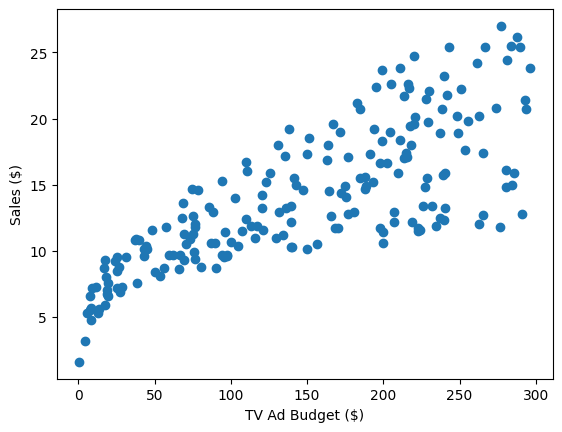

In [3]:
plt.scatter(data['TV Ad Budget ($)'], data['Sales ($)'])
plt.xlabel("TV Ad Budget ($)")
plt.ylabel("Sales ($)")
plt.show()

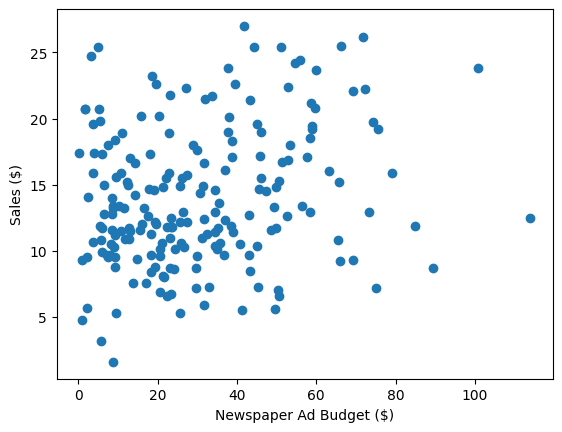

In [4]:
plt.scatter(data['Newspaper Ad Budget ($)'], data['Sales ($)'])
plt.xlabel("Newspaper Ad Budget ($)")
plt.ylabel("Sales ($)")
plt.show()

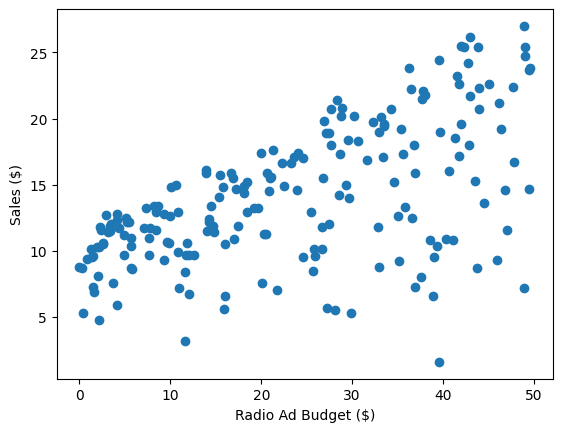

In [5]:
plt.scatter(data['Radio Ad Budget ($)'], data['Sales ($)'])
plt.xlabel("Radio Ad Budget ($)")
plt.ylabel("Sales ($)")
plt.show()

> *TV Ad Budget seems to be the most contributing feature towards the target(Sales ($)).*

# Data Preprocessing

In [6]:
data.drop(columns="Unnamed: 0", inplace=True)

In [7]:
data.corr()

,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
TV Ad Budget ($),1.000000,0.054809,0.056648,0.782224
Radio Ad Budget ($),0.054809,1.000000,0.354104,0.576223
Newspaper Ad Budget ($),0.056648,0.354104,1.000000,0.228299
Sales ($),0.782224,0.576223,0.228299,1.000000


In [8]:
data = data.dropna()

In [9]:
# Splitting the features and target label
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

X.head()

,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($)
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4


In [10]:
print(X.shape)
print(y.shape)

(200, 3)
(200,)


## Splitting the data

In [11]:
X_train = X.iloc[:140, :].values
y_train = y.iloc[:140].values

# Set testing data and target
X_test = X.iloc[140:, :].values
y_test = y.iloc[140:].values

## Standardize the data

The standardization process involves the following steps:
1. Calculate the mean ($\mu$) and standard deviation ($\sigma$) for each feature in the dataset.
2. For each data point (sample), subtract the mean ($\mu$) of the feature and then divide by the standard deviation ($\sigma$) of the feature.

Mathematically, the standardized value for a feature $x$ in a dataset is calculated as: $$x = {x - \mu \over \sigma}$$

Here, $x$ is the original value of the feature, $\mu$ is the mean of the feature, and $\sigma$ is the standard deviation of the feature.

In [12]:
def standardize_data(X_train, X_test):
    mean = np.mean(X_train, axis=0)
    std = np.std(X_train, axis=0)

    X_train = (X_train - mean) / std
    X_test = (X_test - mean) / std

    return X_train, X_test

In [13]:
X_train, X_test = standardize_data(X_train, X_test)

# Linear Regression Model

Linear regression is a fundamental model in machine learning used for predicting a continuous output variable based on input features. The model function for linear regression is represented as: $$f(x) = wx + b$$

A linear model makes a prediction by simply computing a weighted sum of the input features, plus a constant called the bias term (also called the intercept term).

Linear Regression model output: $$\hat{y} = θ_0 + θ_1x_1 + θ_2x_2 + ⋯ + θ_nx_n$$

Here,
- $\hat{y}$ is the predicted value.
- $n$ is the number of features.
- $x_i$ is the $i^{th}$ feature value.
- $θ_j$ is the $j^{th}$ model parameter, including the bias term $θ_0$ and the feature weights $θ_1,θ_2, ⋯, θ_n$.

## Normal Equation (Closed form solution)

To find the value of $θ$ that minimizes the MSE, there exists a closed-form solution—in other words, a mathematical equation that gives the result directly. This is called the Normal equation: $$\hat\theta = {(X^{⊺}X)}^{-1}X^⊺y$$

Here,
- $\hat\theta$ is the value of $\theta$ that minimizes the cost function.
- $y$ is the vector of target values containing $y^{(1)}$ to $y^{(m)}$.

> scikit-learn's LinearRegression class primarily uses the normal equation (specifically, the Moore-Penrose pseudoinverse) to solve for optimal coefficients directly via the closed-form solution.

In Linear Regression with the normal equation, we multipy the parameter vector with the feature vector directly, there is no step for adding the bias separately. So we add a feature with ones in the data, such that the output is like this: $$\hat{y} = θ_0 + θ_1x_1 + θ_2x_2 + ⋯ + θ_nx_n$$
Here, $\theta_0$ is your bias and it naturally gets multiplied by 1 every time, making it a constant addition.

Now we can use $\hat\theta$, for making a prediction: $$y = X^⊺.\hat\theta$$

Now we all know that the closed-form solution provides the best parameters in one go, but what's the secret behind the normal equation, let's see.

The normal equation is a closed-form analytical approach to solving linear regression that calculates the optimal parameter vector directly in one step, without iterations. It minimizes the cost function (Mean Squared Error) by setting the gradient of the parameter vector $\theta$ to zero. Let's see how. We minimize the mean squared error cost: $$J(\theta) = {1\over2m}{(X\theta - y)}^T(X\theta - y)$$

Expand the cost function: $$J(\theta) = {1\over2m}(\theta^TX^TX\theta + y^Ty - 2\theta^TX^Ty)$$
Calculate the gradient: $$\nabla_\theta{J} = {1\over2m}(2X^TX\theta - 2X^Ty)$$
Set the gradient to zero: $$\nabla_\theta{J} = 0$$
$$X^TX\theta - X^Ty = 0$$
Solve for $\theta$: $$\theta = {(X^TX)}^{-1}X^Ty$$

If (X^TX) is not invertible, we compute: $$\theta = X^+y$$
The Normal equation may not work if the matrix $X^TX$ is not invertible (i.e., singular), such as if m < n or if some features are redundant, but the pseudoinverse is always defined.

In [14]:
def LinearRegression(X, y):
    X = np.c_[np.ones((X.shape[0], 1)), X]
    theta_best = np.dot(np.linalg.pinv(np.dot(X.T, X)), np.dot(X.T, y))
    return theta_best

def predict(X, theta):
    X = np.c_[np.ones((X.shape[0], 1)), X]
    return np.dot(X, theta)

In [15]:
theta = LinearRegression(X_train, y_train)
theta

array([14.14785714,  4.06626237,  2.6331071 , -0.06758161])

## Gradient Descent

Gradient descent is a generic optimization algorithm capable of finding optimal solutions using an iterative approach. The general idea of gradient descent is to tweak parameters iteratively in order to minimize a cost function.

<img src="https://bradleyboehmke.github.io/HOML/10-gradient-boosting_files/figure-html/gradient-descent-fig-1.png" width="500" height="280">

In [16]:
class LinearRegressionGD:
    """
    Linear Regression Model with Gradient Descent

    Linear regression is a supervised machine learning algorithm used for modeling the relationship
    between a dependent variable (target) and one or more independent variables (features) by
    fitting a linear equation to the observed data.
    
    Parameters:
        learning_rate(float): The learning rate used in gradient descent
        convergence_tol (float, optional): The tolerance for convergence (stopping criterion). Defaults to 1e-6.

    Attributes:
        W (numpy.ndarray): Coefficients (weights) for the linear regression model.
        b (float): Intercept (bias) for the linear regression model.

    Methods:
        initialize_parameters(n_features): Initialize model parameters.
        forward(X): Compute the forward pass of the linear regression model.
        compute_cost(predictions): Compute the mean squared error cost.
        backward(predictions): Compute gradients for model parameters.
        fit(X, y, iterations, plot_cost=True): Fit the linear regression model to training data.
        predict(X): Predict target values for new input data.
        save_model(filename=None): Save the trained model to a file using pickle.
        load_model(filename): Load a trained model from a file using pickle.
        
    """

    def __init__(self, learning_rate, convergence_tol=1e-6):
        self.learning_rate = learning_rate
        self.convergence_tol = convergence_tol
        self.W = None
        self.b = None

    def initialize_parameters(self, n_features):
        """
        Initialize Model parameters
        Parameters:
            n_features (int):  The number of features in the input data
        """

        self.W = np.random.rand(n_features) * 0.01
        self.b = 0.0

    def forward(self, X):
        """
        Compute the forward pass of the linear regression model

        Parameters:
            X (numpy.ndarray): Input data of shape (m, n_features)

        Returns:
            numpy.ndarray: Predictions of shape (m,).
        """
        return np.dot(X, self.W) + self.b

    def compute_cost(self, predictions):
        """
        Compute the mean squared error cost.

        Parameters:
            predictions (numpy.ndarray): Predictions of shape (m,).

        Returns:
            float: Mean squared error cost.
        """
        m = len(predictions)
        cost = np.sum(np.square(predictions - self.y)) / (2 * m)
        return cost

    def compute_R2(self, predictions):
        """
        Compute the R-squared score

        Parameters:
            predictions (numpy.ndarray): Predictions of shape (m,).

        Returns:
            float: R-squared score.
        """
        # Sum of squares of residuals
        SSres = np.sum(np.square(predictions - self.y))
        y_mean = np.mean(self.y)
        # Total sum of squares
        SStot = np.sum(np.square(self.y - y_mean))
        r2_score = 1 - (SSres / SStot)
        return r2_score

    def backward(self, predictions):
        """
        Compute gradients for model parameters

        Parameters:
            predictions (numpy.ndarray): Predictions of shape (m,)

        Updates:
            numpy.ndarray: Gradient of W
            float: Gradient of b
        """
        m = len(predictions)
        self.dW = np.dot(predictions - self.y, self.X) / m
        self.db = np.sum(predictions - self.y) / m

    def fit(self, X, y, iterations, plot_cost=True):
        """
        Fit the linear regression model to the training data.

        Parameters:
            X (numpy.ndarray): Training input data of shape (m, n_features).
            y (numpy.ndarray): Training labels of shape (m,).
            iterations (int): The number of iterations for gradient descent.
            plot_cost (bool, optional): Whether to plot the cost during training. Defaults to True.

        Raises:
            AssertionError: If input data and labels are not NumPy arrays or have mismatched shapes.

        Plots:
            Plotly line chart showing cost vs. iteration (if plot_cost is True).
        """
        assert isinstance(X, np.ndarray), "X must be a NumPy array"
        assert isinstance(y, np.ndarray), "y must be a NumPy array"
        assert X.shape[0] == y.shape[0], "X and y must have the same number of samples"
        assert iterations > 0, "Iterations must be greater than 0"

        self.X = X
        self.y = y
        self.initialize_parameters(X.shape[1])
        costs = []

        for i in range(iterations):
            # Forward pass
            predictions = self.forward(X)
            cost = self.compute_cost(predictions)
            r2_score = self.compute_R2(predictions)
            # Backward pass
            self.backward(predictions)
            self.W -= self.learning_rate * self.dW
            self.b -= self.learning_rate * self.db
            costs.append(cost)

            if i % 100 == 0:
                print(f'Iteration: {i}, Cost: {cost}, R² score: {r2_score}')
            if i > 0 and abs(costs[-1] - costs[-2]) < self.convergence_tol:
                print(f'Converged after {i} iterations')
                n_iterations = i
                break
                
        plt.plot(np.arange(n_iterations+1), costs, linewidth=3)
        plt.title("Cost vs Iterations", fontsize=14)
        plt.xlabel("Iterations", fontsize=12)
        plt.ylabel("Cost", fontsize=12)
        plt.grid(True)
        plt.show()

    def predict(self, X):
        """
        Predict target values for new input data.

        Parameters:
            X (numpy.ndarray): Input data of shape (m, n_features).

        Returns:
            numpy.ndarray: Predicted target values of shape (m,).
        """
        return self.forward(X)

    def save_model(self, filename=None):
        model_data = {
            'learning_rate': self.learning_rate,
            'convergence_tol': self.convergence_tol,
            'W': self.W,
            'b': self.b
        }

        with open(filename, 'wb') as file:
            pickle.dump(model_data, file)

    @classmethod
    def load_model(cls, filename):
        with open(filename, 'rb') as file:
            model_data = pickle.load(file)

        # Create a new instance of the class and initialize it with the loaded parameters
        loaded_model = cls(model_data['learning_rate'], model_data['convergence_tol'])
        loaded_model.W = model_data['W']
        loaded_model.b = model_data['b']

        return loaded_model

Iteration: 0, Cost: 113.81009351232186, R² score: -7.259143496580034
Iteration: 100, Cost: 16.364282779936644, R² score: -0.18754809461146427
Iteration: 200, Cost: 3.4755705625654016, R² score: 0.7477795235656386
Iteration: 300, Cost: 1.7417844621305518, R² score: 0.8735995431609744
Iteration: 400, Cost: 1.5041793532175085, R² score: 0.8908424311111621
Iteration: 500, Cost: 1.4706426176787102, R² score: 0.8932761758052723
Iteration: 600, Cost: 1.4656571275751236, R² score: 0.8936379704132509
Iteration: 700, Cost: 1.464849631235262, R² score: 0.8936965700324768
Converged after 768 iterations


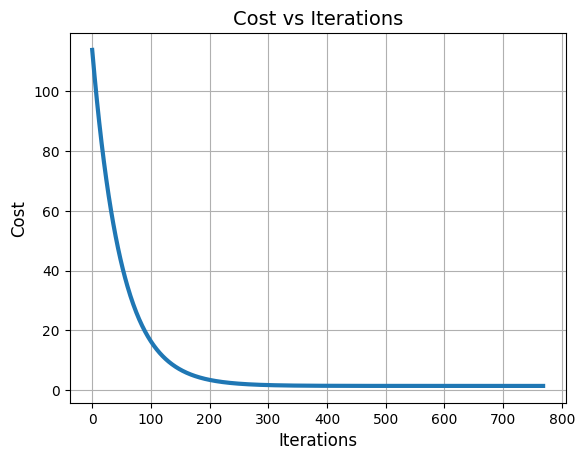

In [17]:
model = LinearRegressionGD(0.01)
model.fit(X_train, y_train, 1000)

In [18]:
model.save_model("model.pkl")

# Evaluation

In [19]:
model = LinearRegressionGD.load_model("model.pkl")

In [20]:
class RegressionMetrics:
    @staticmethod
    def mean_squared_error(y_true, y_pred):
        mse = np.mean((y_true - y_pred) ** 2)
        return mse

    @staticmethod
    def root_mean_squared_error(y_true, y_pred):
        mse = RegressionMetrics.mean_squared_error(y_true, y_pred)
        rmse = np.sqrt(mse)
        return rmse

    @staticmethod
    def r2_score(y_true, y_pred):
        # Sum of squares of residuals
        SSres = np.sum(np.square(y_pred - y_true))
        y_mean = np.mean(y_true)
        # Total sum of squares
        SStot = np.sum(np.square(y_true - y_mean))
        r2_score = 1 - (SSres / SStot)
        return r2_score

In [21]:
y_pred_GD = model.predict(X_test)
mse_value_GD = RegressionMetrics.mean_squared_error(y_test, y_pred_GD)
rmse_value_GD = RegressionMetrics.root_mean_squared_error(y_test, y_pred_GD)
r_squared_value_GD = RegressionMetrics.r2_score(y_test, y_pred_GD)

y_pred_normal = predict(X_test, theta)
mse_value_normal = RegressionMetrics.mean_squared_error(y_test, y_pred_normal)
rmse_value_normal = RegressionMetrics.root_mean_squared_error(y_test, y_pred_normal)
r_squared_value_normal = RegressionMetrics.r2_score(y_test, y_pred_normal)

results = pd.DataFrame({
    "LR Gradient Descent": [mse_value_GD, rmse_value_GD, r_squared_value_GD],
    "LR Normal Equation": [mse_value_normal, rmse_value_normal, r_squared_value_normal]},
    index=["MSE", "RMSE", "R2_score"]
)

In [22]:
results

,LR Gradient Descent,LR Normal Equation
MSE,2.559823,2.557966
RMSE,1.599945,1.599364
R2_score,0.901002,0.901074


*Both models achive a good score, but the closed form solution provides the best parameters in one go!*

# Visualizing the results

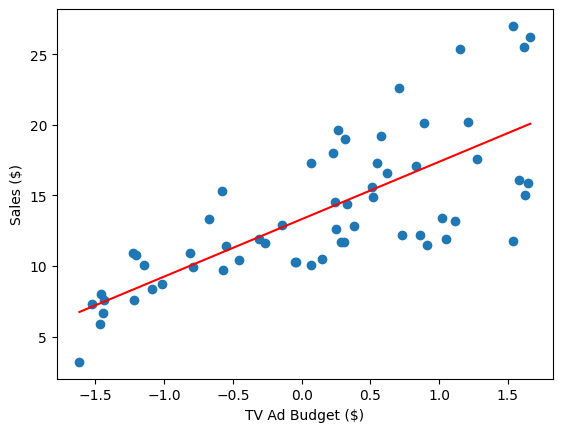

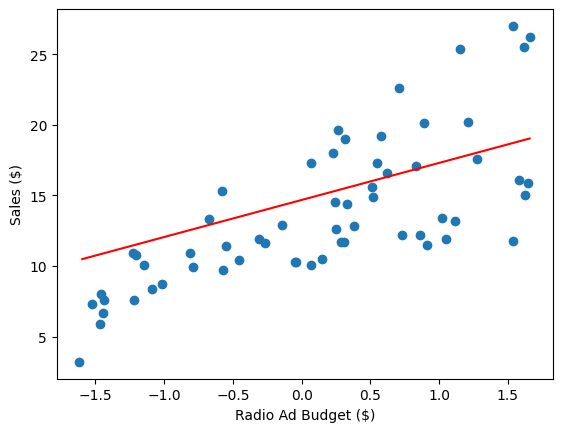

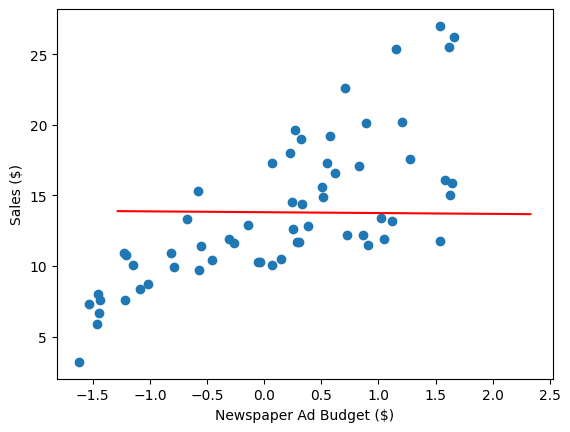

In [23]:
# Choose feature 0 to visualize
X_line_1 = np.linspace(X_test[:,0].min(), X_test[:,0].max(), 100)
X_line_2 = np.linspace(X_test[:,1].min(), X_test[:,1].max(), 100)
X_line_3 = np.linspace(X_test[:,2].min(), X_test[:,2].max(), 100)

# Create full feature matrix for each feature plot
X_plot_1 = np.zeros((100, 3))
X_plot_1[:,0] = X_line_1
X_plot_1[:,1] = X_test[:,1].mean()
X_plot_1[:,2] = X_test[:,2].mean()

X_plot_2 = np.zeros((100, 3))
X_plot_2[:,0] = X_test[:,0].mean()
X_plot_2[:,1] = X_line_2
X_plot_2[:,2] = X_test[:,2].mean()

X_plot_3 = np.zeros((100, 3))
X_plot_3[:,0] = X_test[:,0].mean()
X_plot_3[:,1] = X_test[:,1].mean()
X_plot_3[:,2] = X_line_3

# Predict
y_line_1 = model.predict(X_plot_1)
y_line_2 = model.predict(X_plot_2)
y_line_3 = model.predict(X_plot_3)

# Scatter actual data (only feature 0 vs y)
plt.scatter(X_test[:,0], y_test)
plt.plot(X_line_1, y_line_1, color='red')
plt.xlabel("TV Ad Budget ($)")
plt.ylabel("Sales ($)")
plt.show()

# Scatter actual data (only feature 1 vs y)
plt.scatter(X_test[:,0], y_test)
plt.plot(X_line_2, y_line_2, color='red')
plt.xlabel("Radio Ad Budget ($)")
plt.ylabel("Sales ($)")
plt.show()

# Scatter actual data (only feature 2 vs y)
plt.scatter(X_test[:,0], y_test)
plt.plot(X_line_3, y_line_3, "r-", label="Predictions")
plt.xlabel("Newspaper Ad Budget ($)")
plt.ylabel("Sales ($)")
plt.show()

### Thank You!

<div style="background-color:#D0FF1D; padding:20px; border-radius: 8px; color: #000; text-decoration: none;">
    <div style="font-weight: 700; font-size: 38px; text-align: center;">Machine Learning Algorithms From Scratch</div>
    <a href="https://www.kaggle.com/code/aakcodebreaker/linear-regression-from-scratch" style="color:#000; text-decoration:underline; font-size: 26px">1. Linear Regression</a>
    <br>
    <a href="https://www.kaggle.com/code/aakcodebreaker/logistic-regression-from-scratch" style="color:#000; text-decoration: underline; font-size: 26px;">2. Logistic Regression</a>
    <br>
    <a href="https://www.kaggle.com/code/aakcodebreaker/svm-classification-from-scratch" style="color:#000; text-decoration: underline; font-size: 26px;">3. SVM Classification</a>
</div>